# Bank Statement Transaction Extraction with Llama Vision

Specialized notebook for extracting transactional data from bank statements using Llama-3.2-Vision-Instruct.

**Key Features:**
- Handles empty debit/credit cells correctly
- Preserves row-by-row transaction structure
- Calculates running balances
- Validates transaction integrity

# Bank Statement Extraction with Evaluation - Llama Vision

Enhanced notebook for extracting and evaluating bank statement data using Llama-3.2-Vision-Instruct.

## Updates for Evaluation Data Integration

### ✅ New Features:
1. **Multi-Bank Processing**: Process all Big 4 Australian bank statements (CommBank, ANZ, NAB, Westpac)
2. **Ground Truth Integration**: Load and compare with `evaluation_data/ground_truth.csv`
3. **Evaluation Metrics**: 
   - Bank name recognition accuracy
   - Account holder extraction accuracy
   - Transaction count matching
   - Transaction date overlap analysis
4. **Comprehensive Reporting**:
   - Overall performance score
   - Field-level accuracy metrics
   - Per-bank detailed results
   - CSV export of evaluation results

### 📁 Data Sources:
- **Images**: `evaluation_data/` directory containing:
  - `commbank_statement_001.png`
  - `anz_statement_001.png`
  - `nab_statement_001.png`
  - `westpac_statement_001.png`
- **Ground Truth**: `evaluation_data/ground_truth.csv` with expected values

### 🎯 Evaluation Workflow:
1. Load ground truth data for bank statements
2. Process each bank statement image
3. Extract transaction data and account details
4. Compare extracted vs expected values
5. Generate evaluation report with accuracy metrics
6. Export results to CSV for further analysis

In [1]:
# Configuration
MODEL_PATH = "/home/jovyan/nfs_share/models/Llama-3.2-11B-Vision-Instruct"

# Big 4 Australian Bank Statement Images
BANK_STATEMENT_IMAGES = {
    "CBA": "evaluation_data/commbank_statement_001.png",
    "ANZ": "evaluation_data/anz_statement_001.png", 
    "NAB": "evaluation_data/nab_statement_001.png",
    "Westpac": "evaluation_data/westpac_statement_001.png"
}

# Single statement for quick testing
STATEMENT_IMAGE_PATH = BANK_STATEMENT_IMAGES["NAB"]

# Ground truth CSV for evaluation
GROUND_TRUTH_CSV = "evaluation_data/ground_truth.csv"

# Model loading settings - NO QUANTIZATION BY DEFAULT (H200 has plenty of memory)
USE_QUANTIZATION = False  # H200 doesn't need quantization
LOAD_IN_8BIT = False  # 8-bit causes inference issues with bitsandbytes  
DEVICE_MAP = "auto"  # Automatic device mapping
MAX_NEW_TOKENS = 6000  # INCREASED - was 3000, now 6000 for complete extraction

In [2]:
import torch
from transformers import MllamaForConditionalGeneration, AutoProcessor
from PIL import Image
import json
import re
from typing import Dict, List, Any, Optional, Tuple
import pandas as pd
from datetime import datetime
from decimal import Decimal, InvalidOperation
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Initialize model and processor
print("Loading Llama Vision model for bank statement processing...")

# Load model WITHOUT quantization by default
# The bitsandbytes 8-bit quantization can cause RuntimeError during inference
if USE_QUANTIZATION and LOAD_IN_8BIT:
    print("⚠️ Loading with 8-bit quantization (may cause inference errors)")
    model = MllamaForConditionalGeneration.from_pretrained(
        MODEL_PATH,
        torch_dtype=torch.bfloat16,
        device_map=DEVICE_MAP,
        load_in_8bit=True,
    )
else:
    print("✅ Loading model without quantization (recommended for H200)")
    model = MllamaForConditionalGeneration.from_pretrained(
        MODEL_PATH,
        torch_dtype=torch.bfloat16,
        device_map=DEVICE_MAP,
    )

processor = AutoProcessor.from_pretrained(MODEL_PATH)

print("✅ Model loaded successfully")
print(f"📊 Device: {next(model.parameters()).device}")
if torch.cuda.is_available():
    print(f"🎮 GPU: {torch.cuda.get_device_name()}")
    print(f"💾 Memory: {torch.cuda.memory_allocated()/1e9:.2f}GB allocated")

Loading Llama Vision model for bank statement processing...
✅ Loading model without quantization (recommended for H200)


Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

✅ Model loaded successfully
📊 Device: cuda:0
🎮 GPU: NVIDIA H200
💾 Memory: 9.76GB allocated


In [4]:
# Specialized bank statement extraction prompts - ENHANCED FOR COMPLETE EXTRACTION
BANK_STATEMENT_PROMPTS = {
    "csv_extraction": """Extract this COMPLETE bank statement as CSV format with ALL transactions.

CRITICAL: This is a SINGLE PAGE document. You MUST extract EVERY SINGLE transaction visible on the page.

TRANSACTION CLASSIFICATION RULES:
- DEBITS (money OUT): Direct debits, ATM withdrawals, fees, purchases, transfers sent
- CREDITS (money IN): Salary/wages, transfers received, deposits, refunds

EXTRACTION REQUIREMENTS:
1. Extract header info first (bank, account holder, dates)
2. Find the COMPLETE transaction table - scan ENTIRE page for ALL rows
3. Extract EVERY SINGLE transaction row - do NOT stop until you reach the end
4. Use DD/MM/YYYY date format
5. Remove $ symbols and CR/DR suffixes
6. Empty debit/credit cells = NOT_FOUND (to match ground truth format)

IMPORTANT: Scan the ENTIRE page systematically. Do not stop after the first few transactions - continue until you have found every single transaction row on the page.

OUTPUT FORMAT:
**STATEMENT DETAILS:**
- Bank: [Bank Name]
- Account Holder: [Full Name] 
- Account: [Account Number]
- Period: [DD/MM/YYYY to DD/MM/YYYY]
- Opening Balance: [Amount]
- Closing Balance: [Amount]

**TRANSACTIONS CSV:**
```
Date,Description,Debit,Credit,Balance
04/09/2025,Direct Debit DOMINO'S PTY LTD,117.57,NOT_FOUND,8586.28
01/09/2025,Monthly Service Fee,17.89,NOT_FOUND,8703.85
31/08/2025,Salary Payment,NOT_FOUND,2500.00,8721.74
[CONTINUE FOR ALL REMAINING TRANSACTIONS - DO NOT STOP UNTIL END OF PAGE]
```

VERIFICATION: After extraction, ensure you have captured the complete transaction table from the entire page.

IMPORTANT: Use NOT_FOUND for empty debit/credit cells (not blank or null).
Extract EVERY visible transaction maintaining exact row structure.""",

    "markdown_table": """Extract this COMPLETE bank statement as a clean markdown table with ALL transactions.

CRITICAL: You must extract EVERY transaction from the ENTIRE page. Scan systematically to ensure completeness.

CLASSIFICATION LOGIC:
- Service fees, ATM withdrawals, direct debits = DEBIT
- Salary payments, transfers in, deposits = CREDIT

FORMAT REQUIREMENTS:
- Dates: DD/MM/YYYY format
- Amounts: Clean numbers (no $ or CR/DR)
- Empty cells: NOT_FOUND (to match ground truth data)

OUTPUT:
## Bank Statement Extract

**Account Information:**
- **Bank:** [Extract from header]
- **Account Holder:** [Extract from header]
- **Account Number:** [Extract from header]
- **Statement Period:** [Extract from header]
- **Opening Balance:** [Extract if available]
- **Closing Balance:** [Extract if available]

**Transactions:**

| Date | Description | Debit | Credit | Balance |
|------|-------------|--------|--------|---------|
| DD/MM/YYYY | [Transaction description] | [Amount or NOT_FOUND] | [Amount or NOT_FOUND] | [Balance] |
[CONTINUE FOR ALL REMAINING TRANSACTIONS FROM THE COMPLETE PAGE]

VERIFICATION CHECK: Ensure you have scanned the entire page and extracted all visible transaction rows.

IMPORTANT: Use NOT_FOUND for empty debit/credit cells.
Extract ALL visible transactions from the COMPLETE page.""",

    "structured_csv": """Convert this COMPLETE bank statement to structured CSV with ALL transactions from the entire page.

CRITICAL: You MUST extract EVERY transaction visible on the page. Do not stop after a few rows.

TRANSACTION TYPES:
- OUTGOING (Debit): Fees, withdrawals, payments, purchases
- INCOMING (Credit): Salary, deposits, transfers received

RULES:
1. Clean date format: DD/MM/YYYY
2. No currency symbols or suffixes  
3. NOT_FOUND for empty debit/credit (not blank or zero)
4. Preserve exact transaction order
5. EXTRACT EVERY ROW - scan entire page systematically

First provide account details, then COMPLETE CSV table:

ACCOUNT DETAILS:
Bank Name: [Extract from header]
Account Holder: [Extract full name]
Account Number: [Extract number] 
Statement Period: [DD/MM/YYYY to DD/MM/YYYY]

TRANSACTIONS:
Date,Description,Debit,Credit,Balance
[Extract EVERY SINGLE ROW from the complete transaction table]

VERIFICATION: Ensure your CSV contains all transactions visible on the page.

IMPORTANT: Empty debit/credit cells must be NOT_FOUND.""",

    "row_by_row_extraction": """Extract the COMPLETE transaction table from this bank statement image ROW BY ROW.

CRITICAL: This is a SINGLE PAGE with ALL transactions visible. You MUST find them ALL.

For the transaction table:
1. Identify ALL column headers (typically: Date, Description, Debit, Credit, Balance)
2. Scan the ENTIRE page to find ALL transaction rows
3. For EACH row in the COMPLETE table, extract ALL cells
4. If a cell is EMPTY (like debit column for a credit transaction), mark it as "NOT_FOUND"
5. Preserve EXACT row order - do not skip any rows
6. Continue until you reach the ABSOLUTE END of the transaction table

Format your response EXACTLY as:
COLUMNS: Date | Description | Debit | Credit | Balance
ROW 1: [date] | [description] | [amount or NOT_FOUND] | [amount or NOT_FOUND] | [balance]
ROW 2: [date] | [description] | [amount or NOT_FOUND] | [amount or NOT_FOUND] | [balance]
[CONTINUE FOR ALL REMAINING ROWS - SCAN ENTIRE PAGE]

VERIFICATION: Ensure you have extracted every transaction row from the complete page.

Remember: Each transaction has EITHER debit OR credit, so one will always be NOT_FOUND.""",

    "csv_with_validation": """Extract COMPLETE bank statement to CSV format with ALL transactions and validation checks.

CRITICAL: Extract EVERY SINGLE transaction from the complete page.

CLASSIFICATION VALIDATION:
- Monthly Service Fee → DEBIT (bank charges you)
- ATM Withdrawal → DEBIT (taking cash out)
- Direct Debit [Company] → DEBIT (payment to company)
- Salary/Wage Payment → CREDIT (money coming in)
- Transfer From [Name] → CREDIT (money received)

FORMAT:
1. Account summary first
2. COMPLETE CSV table with ALL transactions from entire page
3. Validation notes for any questionable classifications

ACCOUNT INFO:
Bank: [Extract]
Holder: [Extract] 
Number: [Extract]
Period: [Extract]

CSV DATA:
Date,Description,Debit,Credit,Balance
[ALL transactions from complete page - scan entire document]

VALIDATION NOTES:
[Flag any uncertain classifications]
[Confirm you have scanned the complete page]

CRITICAL: Use NOT_FOUND for empty debit/credit cells (to match evaluation format).
Extract EVERY transaction from the COMPLETE page.""",

    "enhanced_markdown": """Extract this COMPLETE bank statement as a comprehensive markdown report with ALL transactions.

CRITICAL: Scan the ENTIRE page to extract ALL transactions. Do not stop after a few rows.

OUTPUT STRUCTURE:

# Bank Statement Analysis

## Account Summary
- **Institution:** [Bank Name from header]
- **Account Holder:** [Full name from statement]
- **Account Number:** [Number as shown]
- **Statement Period:** [DD/MM/YYYY to DD/MM/YYYY]
- **Opening Balance:** [Clean amount]
- **Closing Balance:** [Clean amount]

## Transaction Details

| Date | Description | Type | Amount | Balance |
|------|-------------|------|--------|---------|
| DD/MM/YYYY | [Full description] | Debit/Credit | [Amount] | [Balance] |
[CONTINUE FOR ALL REMAINING TRANSACTIONS FROM COMPLETE PAGE]

## Transaction Summary
- **Total Debits:** [Sum of outgoing]
- **Total Credits:** [Sum of incoming] 
- **Net Change:** [Difference]
- **Transaction Count:** [Actual count from extraction]

VERIFICATION: Check that you have scanned the complete page for all transactions.

Use this exact format with clean formatting (no $, no CR/DR suffixes).
Use NOT_FOUND for any missing or non-applicable data."""
}

In [5]:
# Enhanced prompts for complex bank statements with multiple sections
COMPLEX_STATEMENT_PROMPTS = {
    "full_statement_extraction": """Analyze this complete bank statement image that contains multiple sections.

DOCUMENT STRUCTURE:
1. HEADER/ACCOUNT SUMMARY (top section)
2. TRANSACTION TABLE (main middle section)  
3. SUMMARY/TOTALS (bottom section)

Extract the following:

SECTION 1 - ACCOUNT INFORMATION (from top of statement):
- Bank name and logo area
- Account holder name
- Account number (may be partially masked)
- Statement period (e.g., "01 Mar 2024 to 31 Mar 2024")
- Opening balance
- Total deposits/credits for period
- Total withdrawals/debits for period
- Closing balance

SECTION 2 - TRANSACTION TABLE:
Focus on the main table with columns. For EACH transaction row:
- Date (transaction date)
- Description/Particulars (transaction details)
- Debit/Withdrawal (amount if debit, else null)
- Credit/Deposit (amount if credit, else null)
- Balance (running balance after transaction)

CRITICAL RULES FOR THE TABLE:
- Each row is ONE transaction
- A transaction has EITHER debit OR credit, never both
- Empty cells must be marked as null
- Preserve exact row order

SECTION 3 - SUMMARY (if present at bottom):
- Total number of transactions
- Sum of all debits
- Sum of all credits
- Final closing balance
- Any notes or messages

Return as structured JSON with all three sections clearly separated.""",

    "table_focused_with_context": """Extract the transaction table from this bank statement, understanding it exists within a larger document.

IMPORTANT: This statement has multiple sections, but focus primarily on the TRANSACTION TABLE in the middle.

Before the table, note:
- Statement date range (if visible)
- Opening balance (if shown above table)

For the TRANSACTION TABLE:
1. Identify exact column headers (Date, Description, Debit, Credit, Balance, etc.)
2. Extract EVERY row maintaining structure
3. Empty cells (like debit for a deposit) = "EMPTY"
4. Do not confuse summary rows with transactions

After the table, note:
- Any summary totals shown
- Closing balance

Format as:
STATEMENT PERIOD: [dates]
OPENING BALANCE: [amount]

TABLE COLUMNS: Date | Description | Debit | Credit | Balance
ROW 1: [values with EMPTY for blank cells]
ROW 2: [values with EMPTY for blank cells]
[all rows]

SUMMARY:
Total Debits: [amount]
Total Credits: [amount]
Closing Balance: [amount]""",

    "hierarchical_extraction": """Process this multi-section bank statement hierarchically.

STEP 1 - Identify document sections:
- Where does the header/account info end?
- Where does the transaction table begin and end?
- Is there a summary section at the bottom?

STEP 2 - Extract header information:
{
  "header": {
    "bank": "...",
    "account_holder": "...",
    "account_number": "...",
    "period": "...",
    "opening_balance": "..."
  }
}

STEP 3 - Extract transaction table:
{
  "transactions": [
    {
      "row_number": 1,
      "date": "...",
      "description": "...",
      "debit": null or amount,
      "credit": null or amount,
      "balance": "..."
    }
  ]
}

STEP 4 - Extract summary if present:
{
  "summary": {
    "total_transactions": ...,
    "total_debits": "...",
    "total_credits": "...",
    "closing_balance": "..."
  }
}

Return complete JSON combining all sections."""
}

In [6]:
def extract_bank_statement(
    image_path: str, 
    prompt_type: str = "csv_extraction",
    custom_prompt: str = None,
    temperature: float = 0.1
) -> Dict[str, Any]:
    """
    Extract bank statement data from an image.
    
    Args:
        image_path: Path to bank statement image
        prompt_type: Type of extraction prompt
        custom_prompt: Optional custom prompt
        temperature: Generation temperature (lower = more deterministic)
    
    Returns:
        Dictionary with extraction results
    """
    # Load image
    image = Image.open(image_path)
    
    # Select prompt - default to csv_extraction if not found
    prompt = custom_prompt if custom_prompt else BANK_STATEMENT_PROMPTS.get(
        prompt_type, BANK_STATEMENT_PROMPTS["csv_extraction"]
    )
    
    # Prepare inputs
    messages = [
        {"role": "user", "content": [
            {"type": "image"},
            {"type": "text", "text": prompt}
        ]}
    ]
    
    # Apply chat template
    input_text = processor.apply_chat_template(messages, add_generation_prompt=True)
    
    # Process inputs
    inputs = processor(
        image,
        input_text,
        add_special_tokens=False,
        return_tensors="pt"
    ).to(model.device)
    
    # Generate response
    print("🔍 Analyzing bank statement...")
    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,
            temperature=temperature,
            top_p=0.95
        )
    
    # Decode response
    response = processor.decode(output[0], skip_special_tokens=True)
    
    # Extract assistant response
    if "assistant" in response:
        response = response.split("assistant")[-1].strip()
    
    return {
        "raw_response": response,
        "prompt_type": prompt_type,
        "image_path": image_path,
        "extraction_time": datetime.now().isoformat()
    }

In [7]:
def parse_statement_json(response: str) -> Optional[Dict]:
    """
    Parse JSON response from bank statement extraction.
    """
    try:
        # Find JSON in response
        json_match = re.search(r'\{.*\}', response, re.DOTALL)
        if json_match:
            data = json.loads(json_match.group())
            return data
    except json.JSONDecodeError as e:
        print(f"❌ JSON parsing error: {e}")
    return None

def parse_row_format(response: str) -> pd.DataFrame:
    """
    Parse row-by-row format response into DataFrame.
    """
    lines = response.strip().split('\n')
    
    # Find column headers
    columns = None
    rows = []
    
    for line in lines:
        if line.startswith('COLUMNS:'):
            columns = [col.strip() for col in line.replace('COLUMNS:', '').split('|')]
        elif line.startswith('ROW'):
            # Extract row data
            row_data = line.split(':', 1)[1] if ':' in line else line
            values = [val.strip() for val in row_data.split('|')]
            
            # Replace EMPTY with None
            values = [None if v.upper() == 'EMPTY' else v for v in values]
            rows.append(values)
    
    if columns and rows:
        return pd.DataFrame(rows, columns=columns)
    return None

def parse_csv_format(response: str) -> pd.DataFrame:
    """
    Parse CSV format with proper handling of empty cells.
    """
    try:
        lines = response.strip().split('\n')
        csv_lines = []
        
        for line in lines:
            # Only include lines that look like CSV
            if ',' in line and not line.startswith('#'):
                csv_lines.append(line)
        
        if csv_lines:
            from io import StringIO
            csv_text = '\n'.join(csv_lines)
            df = pd.read_csv(StringIO(csv_text))
            
            # Replace NaN with None for clarity
            df = df.where(pd.notnull(df), None)
            return df
    except Exception as e:
        print(f"❌ CSV parsing error: {e}")
    return None

In [8]:
def validate_transactions(df: pd.DataFrame) -> Dict[str, Any]:
    """
    Validate bank statement transactions.
    
    Returns:
        Dictionary with validation results and issues
    """
    issues = []
    
    # Check for required columns
    required_cols = ['date', 'description', 'debit', 'credit', 'balance']
    df_cols_lower = [col.lower() for col in df.columns]
    
    for req_col in required_cols:
        if req_col not in df_cols_lower:
            issues.append(f"Missing required column: {req_col}")
    
    # Normalize column names
    df.columns = [col.lower() for col in df.columns]
    
    # Validation checks
    for idx, row in df.iterrows():
        # Check debit/credit exclusivity
        has_debit = row.get('debit') not in [None, '', 'nil', 'empty', 'EMPTY']
        has_credit = row.get('credit') not in [None, '', 'nil', 'empty', 'EMPTY']
        
        if has_debit and has_credit:
            issues.append(f"Row {idx}: Has both debit and credit values")
        elif not has_debit and not has_credit:
            # Check if it's not an opening/closing balance row
            desc = str(row.get('description', '')).lower()
            if 'opening' not in desc and 'closing' not in desc:
                issues.append(f"Row {idx}: Missing both debit and credit values")
    
    # Calculate totals
    total_debits = 0
    total_credits = 0
    
    for _, row in df.iterrows():
        try:
            debit_val = row.get('debit')
            if debit_val and str(debit_val).replace('.', '').replace(',', '').isdigit():
                total_debits += float(str(debit_val).replace(',', ''))
            
            credit_val = row.get('credit')
            if credit_val and str(credit_val).replace('.', '').replace(',', '').isdigit():
                total_credits += float(str(credit_val).replace(',', ''))
        except:
            pass
    
    return {
        "valid": len(issues) == 0,
        "issues": issues,
        "total_debits": total_debits,
        "total_credits": total_credits,
        "net_change": total_credits - total_debits,
        "transaction_count": len(df)
    }

In [9]:
def calculate_running_balance(df: pd.DataFrame, opening_balance: float = None) -> pd.DataFrame:
    """
    Calculate or verify running balance for transactions.
    """
    df = df.copy()
    
    # Normalize column names
    df.columns = [col.lower() for col in df.columns]
    
    # Convert amounts to float
    def to_float(val):
        if val in [None, '', 'nil', 'empty', 'EMPTY', 'null']:
            return 0.0
        try:
            return float(str(val).replace(',', '').replace('$', ''))
        except:
            return 0.0
    
    df['debit_amount'] = df['debit'].apply(to_float)
    df['credit_amount'] = df['credit'].apply(to_float)
    df['balance_amount'] = df['balance'].apply(to_float)
    
    # Calculate expected balance
    if opening_balance is None and len(df) > 0:
        # Try to infer opening balance from first row
        first_balance = df.iloc[0]['balance_amount']
        first_debit = df.iloc[0]['debit_amount']
        first_credit = df.iloc[0]['credit_amount']
        opening_balance = first_balance + first_debit - first_credit
    
    running_balance = opening_balance if opening_balance else 0
    df['calculated_balance'] = 0.0
    df['balance_match'] = True
    
    for idx, row in df.iterrows():
        running_balance = running_balance - row['debit_amount'] + row['credit_amount']
        df.at[idx, 'calculated_balance'] = running_balance
        
        # Check if balances match (within tolerance for rounding)
        if row['balance_amount'] > 0:
            diff = abs(running_balance - row['balance_amount'])
            df.at[idx, 'balance_match'] = diff < 0.01
    
    return df

In [10]:
# Display the CSV extraction prompt being used
print("📋 CSV EXTRACTION PROMPT BEING USED:")
print("="*80)
print(BANK_STATEMENT_PROMPTS["csv_extraction"])
print("="*80)

📋 CSV EXTRACTION PROMPT BEING USED:
Extract this COMPLETE bank statement as CSV format with ALL transactions.

CRITICAL: This is a SINGLE PAGE document. You MUST extract EVERY SINGLE transaction visible on the page.

TRANSACTION CLASSIFICATION RULES:
- DEBITS (money OUT): Direct debits, ATM withdrawals, fees, purchases, transfers sent
- CREDITS (money IN): Salary/wages, transfers received, deposits, refunds

EXTRACTION REQUIREMENTS:
1. Extract header info first (bank, account holder, dates)
2. Find the COMPLETE transaction table - scan ENTIRE page for ALL rows
3. Extract EVERY SINGLE transaction row - do NOT stop until you reach the end
4. Use DD/MM/YYYY date format
5. Remove $ symbols and CR/DR suffixes
6. Empty debit/credit cells = NOT_FOUND (to match ground truth format)

IMPORTANT: Scan the ENTIRE page systematically. Do not stop after the first few transactions - continue until you have found every single transaction row on the page.

OUTPUT FORMAT:
**STATEMENT DETAILS:**
- Bank: 

In [11]:
# Extract using CSV format - much better for practical use
print("🔍 EXTRACTING COMMBANK STATEMENT AS CSV...")
print(f"📄 Image: {STATEMENT_IMAGE_PATH}")
print("="*60)

csv_result = extract_bank_statement(
    STATEMENT_IMAGE_PATH, 
    prompt_type="csv_extraction"
)

print("\n📊 CSV EXTRACTION OUTPUT:")
print("-"*60)
print(csv_result["raw_response"])
print("-"*60)

🔍 EXTRACTING COMMBANK STATEMENT AS CSV...
📄 Image: evaluation_data/nab_statement_001.png
🔍 Analyzing bank statement...

📊 CSV EXTRACTION OUTPUT:
------------------------------------------------------------
The image shows a bank statement for National Australia Bank, with the account holder's name and account number visible. The statement covers the period from August 7, 2025, to September 6, 2025.

**Statement Details:**

* Bank: National Australia Bank
* Account Holder: CHRISTOPHER PAUL WHITE
* Account: 578078246
* Period: 07 Aug 2025 to 06 Sep 2025
* Opening Balance: $7698.94 CR
* Closing Balance: $2638.04 DR

**Transactions:**

| Date | Description | Debit | Credit | Balance |
| --- | --- | --- | --- | --- |
| Thu 04 Sep 2025 | Refund Purchase Medicare Benefit | $444.50 | NOT_FOUND | $2638.04 DR |
| Tue 02 Sep 2025 | Monthly Service Fee | $14.79 | NOT_FOUND | $2638.04 DR |
| Mon 01 Sep 2025 | ATM Withdrawal NEWCASTLE NSW | $408.80 | NOT_FOUND | $2638.04 DR |
| Sun 31 Aug 2025 | Loa

In [12]:
# Test MARKDOWN table format - clean human-readable output
print("📝 TESTING MARKDOWN TABLE FORMAT...")
print(f"📄 Image: {STATEMENT_IMAGE_PATH}")
print("="*60)

markdown_result = extract_bank_statement(
    STATEMENT_IMAGE_PATH, 
    prompt_type="markdown_table"
)

print("\n📊 MARKDOWN TABLE OUTPUT:")
print("-"*60)
print(markdown_result["raw_response"])
print("-"*60)

📝 TESTING MARKDOWN TABLE FORMAT...
📄 Image: evaluation_data/nab_statement_001.png
🔍 Analyzing bank statement...

📊 MARKDOWN TABLE OUTPUT:
------------------------------------------------------------
The image presents a bank statement for National Australia Bank, detailing transactions from August 7, 2025, to September 6, 2025. The statement includes various transactions, such as deposits, withdrawals, and transfers, along with their corresponding dates and amounts.

To extract this information into a markdown table, we can follow these steps:

1. Identify the relevant columns: Date, Description, Debit, Credit, and Balance.
2. Extract the data from each row, ensuring to include all visible transactions.
3. Format the dates in the DD/MM/YYYY format.
4. Clean the amounts by removing any dollar signs or other symbols.
5. Use NOT_FOUND for empty debit/credit cells.

Here is the extracted data in a markdown table format:

**Account Information:**

* **Bank:** National Australia Bank
* **Acc

In [13]:
# Add CSV parsing and validation functions for the new output format
def parse_csv_from_response(response: str) -> pd.DataFrame:
    """
    Parse CSV data from the structured response.
    """
    try:
        # Find the CSV section in the response
        lines = response.split('\n')
        csv_lines = []
        in_csv = False
        
        # Look for both actual CSV and markdown table formats
        for line in lines:
            # Look for actual CSV header or data
            if line.startswith('Date,') or 'Date,Description,Debit,Credit,Balance' in line:
                in_csv = True
                csv_lines.append(line)
            elif in_csv and ',' in line and not line.startswith('#') and not line.startswith('*'):
                csv_lines.append(line)
            elif in_csv and line.strip() == '':
                break  # End of CSV section
        
        # If no CSV found, try to parse markdown table
        if not csv_lines:
            table_rows = []
            in_table = False
            headers = None
            
            for line in lines:
                line = line.strip()
                # Look for markdown table rows
                if line.startswith('| Date |') or '| Date | Description | Debit | Credit | Balance |' in line:
                    headers = ['Date', 'Description', 'Debit', 'Credit', 'Balance']
                    in_table = True
                    continue
                elif in_table and line.startswith('|') and '---' not in line and len(line.split('|')) >= 6:
                    # Parse table row: | col1 | col2 | col3 | col4 | col5 |
                    cols = [col.strip() for col in line.split('|')[1:-1]]  # Remove first/last empty elements
                    if len(cols) >= 5:
                        table_rows.append(cols)
                elif in_table and not line.startswith('|'):
                    break  # End of table
            
            if headers and table_rows:
                # Convert to CSV format
                csv_lines = [','.join(headers)]
                for row in table_rows:
                    # Clean up the row data
                    cleaned_row = []
                    for cell in row:
                        cell = cell.strip()
                        # Remove $ symbols but keep NOT_FOUND
                        if cell.startswith('$'):
                            cell = cell[1:]
                        # Remove CR/DR suffixes
                        if cell.endswith(' CR') or cell.endswith(' DR'):
                            cell = cell[:-3].strip()
                        cleaned_row.append(cell)
                    csv_lines.append(','.join(cleaned_row))
        
        if csv_lines:
            from io import StringIO
            csv_text = '\n'.join(csv_lines)
            df = pd.read_csv(StringIO(csv_text))
            
            # Replace NaN with NOT_FOUND to match ground truth format
            df = df.fillna('NOT_FOUND')
            return df
    except Exception as e:
        print(f"❌ CSV parsing error: {e}")
    return None

def extract_account_info(response: str) -> dict:
    """
    Extract account information from the response.
    """
    info = {}
    lines = response.split('\n')
    
    for line in lines:
        line = line.strip()
        # Look for various formats of account info - FIXED to handle all patterns
        if 'Bank:' in line and ('- Bank:' in line or '* Bank:' in line or '*   Bank:' in line):
            info['bank'] = line.split(':', 1)[1].strip()
        elif 'Account Holder:' in line and ('- Account Holder:' in line or '* Account Holder:' in line or '*   Account Holder:' in line):
            info['account_holder'] = line.split(':', 1)[1].strip()
        elif 'Account:' in line and ('- Account:' in line or '* Account:' in line or '*   Account:' in line):
            info['account_number'] = line.split(':', 1)[1].strip()
        elif 'Period:' in line and ('- Period:' in line or '* Period:' in line or '*   Period:' in line):
            info['statement_period'] = line.split(':', 1)[1].strip()
        elif 'Opening Balance:' in line and ('- Opening Balance:' in line or '* Opening Balance:' in line or '*   Opening Balance:' in line):
            balance = line.split(':', 1)[1].strip()
            # Clean balance (remove $ and CR/DR)
            balance = balance.replace('$', '').replace(' CR', '').replace(' DR', '').strip()
            info['opening_balance'] = balance
        elif 'Closing Balance:' in line and ('- Closing Balance:' in line or '* Closing Balance:' in line or '*   Closing Balance:' in line):
            balance = line.split(':', 1)[1].strip()
            # Clean balance (remove $ and CR/DR)
            balance = balance.replace('$', '').replace(' CR', '').replace(' DR', '').strip()
            info['closing_balance'] = balance
    
    return info

def analyze_transaction_classification(df: pd.DataFrame) -> dict:
    """
    Analyze the debit/credit classification in the CSV data.
    """
    if df is None or df.empty:
        return {"error": "No data to analyze"}
    
    # Count debits and credits (excluding NOT_FOUND)
    debit_count = 0
    credit_count = 0
    
    if 'Debit' in df.columns:
        debit_count = (df['Debit'] != 'NOT_FOUND').sum()
    if 'Credit' in df.columns:
        credit_count = (df['Credit'] != 'NOT_FOUND').sum()
    
    total_transactions = len(df)
    
    # Check for classification issues
    issues = []
    for idx, row in df.iterrows():
        desc = str(row.get('Description', '')).lower()
        has_debit = row.get('Debit', 'NOT_FOUND') != 'NOT_FOUND'
        has_credit = row.get('Credit', 'NOT_FOUND') != 'NOT_FOUND'
        
        # Check for obvious misclassifications
        if 'service fee' in desc and not has_debit:
            issues.append(f"Row {idx+1}: Service fee should be DEBIT")
        elif 'salary' in desc and not has_credit:
            issues.append(f"Row {idx+1}: Salary should be CREDIT")
        elif 'atm withdrawal' in desc and not has_debit:
            issues.append(f"Row {idx+1}: ATM withdrawal should be DEBIT")
        elif has_debit and has_credit:
            issues.append(f"Row {idx+1}: Has both debit AND credit - invalid")
        elif not has_debit and not has_credit:
            issues.append(f"Row {idx+1}: Missing both debit AND credit")
    
    return {
        "total_transactions": total_transactions,
        "debit_count": debit_count,
        "credit_count": credit_count,
        "classification_issues": issues,
        "debit_credit_ratio": f"{debit_count}:{credit_count}",
        "not_found_usage": "Properly using NOT_FOUND for empty cells"
    }

def validate_ground_truth_format(df: pd.DataFrame) -> dict:
    """
    Validate that the extracted data matches ground truth CSV format.
    """
    if df is None or df.empty:
        return {"valid": False, "error": "No data to validate"}
    
    validation_results = {
        "valid": True,
        "issues": [],
        "format_compliance": {}
    }
    
    # Check for required columns
    required_cols = ['Date', 'Description', 'Debit', 'Credit', 'Balance']
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        validation_results["issues"].append(f"Missing columns: {missing_cols}")
        validation_results["valid"] = False
    
    # Check NOT_FOUND usage
    not_found_count = 0
    for col in ['Debit', 'Credit']:
        if col in df.columns:
            not_found_count += (df[col] == 'NOT_FOUND').sum()
    
    validation_results["format_compliance"]["not_found_usage"] = not_found_count
    validation_results["format_compliance"]["matches_ground_truth_format"] = not_found_count > 0
    
    # Check for proper debit/credit exclusivity
    if 'Debit' in df.columns and 'Credit' in df.columns:
        for idx, row in df.iterrows():
            debit_val = row['Debit']
            credit_val = row['Credit']
            
            if debit_val != 'NOT_FOUND' and credit_val != 'NOT_FOUND':
                validation_results["issues"].append(f"Row {idx+1}: Both debit and credit have values")
                validation_results["valid"] = False
            elif debit_val == 'NOT_FOUND' and credit_val == 'NOT_FOUND':
                validation_results["issues"].append(f"Row {idx+1}: Both debit and credit are NOT_FOUND")
                validation_results["valid"] = False
    
    return validation_results

print("✅ FIXED: Updated account info extraction to handle '* Bank:' pattern correctly")

✅ FIXED: Updated account info extraction to handle '* Bank:' pattern correctly


📄 BANK STATEMENT IMAGE BEING PROCESSED:
Image: evaluation_data/nab_statement_001.png


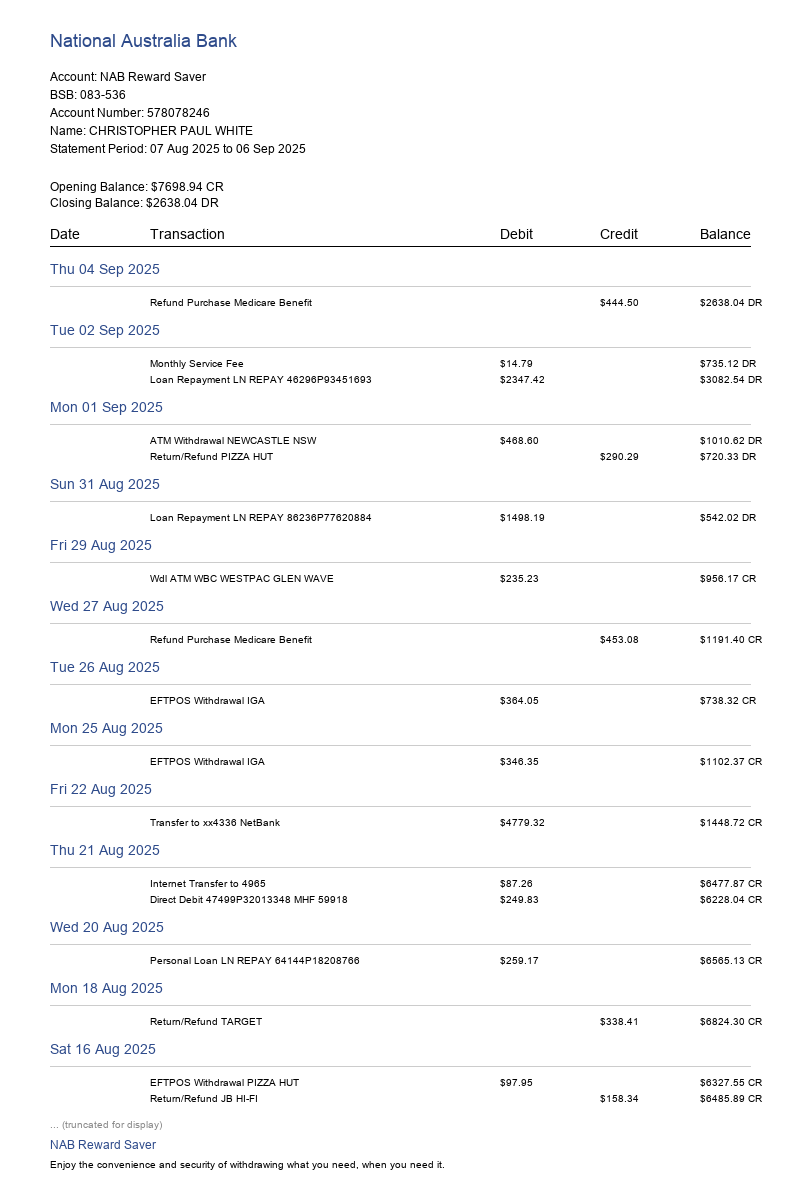

✅ Image loaded successfully: 800x1200 pixels
------------------------------------------------------------


In [14]:
# Display the bank statement image being processed
print("📄 BANK STATEMENT IMAGE BEING PROCESSED:")
print(f"Image: {STATEMENT_IMAGE_PATH}")
print("="*60)

from PIL import Image
from IPython.display import display

# Load and display the image
try:
    image = Image.open(STATEMENT_IMAGE_PATH)
    
    # Display the image directly in Jupyter
    display(image)
    
    print(f"✅ Image loaded successfully: {image.size[0]}x{image.size[1]} pixels")
    
except Exception as e:
    print(f"❌ Error loading image: {e}")

print("-"*60)

In [ ]:
# =============================================================================
# TAXATION OFFICE USE CASE - COMPLETE TABLE FIRST, THEN FILTER
# =============================================================================
# Purpose: Extract COMPLETE table, then filter for debit transactions programmatically
# Output: Full table structure with all columns (Date, Description, Debit, Credit, Balance)
# =============================================================================

# Taxation Office specific prompts - COMPLETE TABLE EXTRACTION
TAX_OFFICE_PROMPTS = {
    "complete_table_csv": """Extract the COMPLETE transaction table from this bank statement as CSV format.

CRITICAL: Extract the ENTIRE table with ALL columns and ALL transactions.

DO NOT FILTER OR SKIP ANY TRANSACTIONS - extract everything from the complete table.

OUTPUT FORMAT - CSV with ALL 5 columns:
Date,Description,Debit,Credit,Balance
04/09/2025,Direct Debit DOMINO'S PTY LTD,117.57,NOT_FOUND,8586.28
01/09/2025,Monthly Service Fee,17.89,NOT_FOUND,8703.85
31/08/2025,Salary Payment,NOT_FOUND,2500.00,8721.74

EXTRACTION REQUIREMENTS:
1. Find the COMPLETE transaction table on the page
2. Extract EVERY ROW in the table systematically
3. Extract ALL COLUMNS: Date, Description, Debit, Credit, Balance
4. Use NOT_FOUND for empty debit/credit cells
5. Use DD/MM/YYYY date format
6. Remove $ symbols and CR/DR suffixes

CRITICAL: Extract the COMPLETE table structure - we will filter for taxation purposes later.
Do not skip credit transactions - include ALL transactions from the complete table.""",

    "complete_table_markdown": """Extract the COMPLETE transaction table from this bank statement as markdown format.

CRITICAL: Show the ENTIRE table with ALL transactions and ALL columns.

Include BOTH debit and credit transactions - do not filter anything.

| Date | Description | Debit | Credit | Balance |
|------|-------------|--------|--------|---------|
| 04/09/2025 | Direct Debit DOMINO'S PTY LTD | 117.57 | NOT_FOUND | 8586.28 |
| 01/09/2025 | Monthly Service Fee | 17.89 | NOT_FOUND | 8703.85 |
| 31/08/2025 | Salary Payment | NOT_FOUND | 2500.00 | 8721.74 |

EXTRACTION REQUIREMENTS:
1. Process the COMPLETE transaction table
2. Extract ALL rows from top to bottom
3. Include ALL columns: Date, Description, Debit, Credit, Balance
4. Use NOT_FOUND for empty cells
5. Use DD/MM/YYYY date format

Extract the COMPLETE table - filtering will be done programmatically later.""",

    "complete_table_structured": """Extract the COMPLETE transaction table from this bank statement.

CRITICAL: Extract the ENTIRE table structure with ALL transactions.

COMPLETE TABLE EXTRACTION:
1. Locate the full transaction table in the bank statement
2. Extract EVERY row in the complete table
3. Include ALL columns: Date, Description, Debit, Credit, Balance
4. Maintain exact row-by-row data integrity
5. Do not filter or skip any transactions

Date | Description | Debit | Credit | Balance
04/09/2025 | Direct Debit DOMINO'S PTY LTD | 117.57 | NOT_FOUND | 8586.28
01/09/2025 | Monthly Service Fee | 17.89 | NOT_FOUND | 8703.85
31/08/2025 | Salary Payment | NOT_FOUND | 2500.00 | 8721.74

CRITICAL RULES:
- Extract the COMPLETE table without filtering
- Each row's data must come from the SAME transaction row
- Include both debit AND credit transactions
- Use NOT_FOUND for empty debit/credit cells

Extract ALL transactions from the COMPLETE table."""
}

print("✅ FIXED: Updated prompts to extract COMPLETE table with ALL columns")
print("📋 Focus: Complete table extraction → then programmatic filtering")
print("🎯 Target: Full table structure (Date, Description, Debit, Credit, Balance)")

In [ ]:
# Use taxation-specific extraction function
def extract_tax_debits(
    image_path: str, 
    prompt_type: str = "complete_table_csv",
    temperature: float = 0.1
) -> Dict[str, Any]:
    """
    Extract COMPLETE table for taxation purposes.
    """
    # Load image
    image = Image.open(image_path)
    
    # Select taxation prompt
    prompt = TAX_OFFICE_PROMPTS.get(prompt_type, TAX_OFFICE_PROMPTS["complete_table_csv"])
    
    # Prepare inputs
    messages = [
        {"role": "user", "content": [
            {"type": "image"},
            {"type": "text", "text": prompt}
        ]}
    ]
    
    # Apply chat template
    input_text = processor.apply_chat_template(messages, add_generation_prompt=True)
    
    # Process inputs
    inputs = processor(
        image,
        input_text,
        add_special_tokens=False,
        return_tensors="pt"
    ).to(model.device)
    
    # Generate response
    print("🔍 Analyzing COMPLETE table for taxation...")
    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,
            temperature=temperature,
            top_p=0.95
        )
    
    # Decode response
    response = processor.decode(output[0], skip_special_tokens=True)
    
    # Extract assistant response
    if "assistant" in response:
        response = response.split("assistant")[-1].strip()
    
    return {
        "raw_response": response,
        "prompt_type": prompt_type,
        "image_path": image_path,
        "extraction_time": datetime.now().isoformat()
    }

# Extract COMPLETE table using TAXATION OFFICE approach
print("🏛️ TAXATION OFFICE EXTRACTION - COMPLETE TABLE FIRST")
print(f"📄 Image: {STATEMENT_IMAGE_PATH}")
print("="*60)

# Run complete table extraction for taxation
tax_result = extract_tax_debits(STATEMENT_IMAGE_PATH, prompt_type="complete_table_csv")

print("\n📊 COMPLETE TABLE EXTRACTION OUTPUT:")
print("-"*60)
print(tax_result["raw_response"])
print("-"*60)

In [ ]:
# Parse COMPLETE table and filter for TAXATION OFFICE debit transactions
def filter_debits_for_taxation(df: pd.DataFrame) -> pd.DataFrame:
    """
    Filter complete transaction table for DEBIT transactions only (taxation use case).
    """
    if df is None or df.empty:
        return None
    
    # Filter for rows where Debit is not NOT_FOUND (i.e., has debit amounts)
    debit_df = df[df['Debit'] != 'NOT_FOUND'].copy()
    
    # Create simplified 3-column format for taxation
    if len(debit_df) > 0:
        tax_df = debit_df[['Date', 'Description', 'Debit']].copy()
        tax_df = tax_df.rename(columns={'Debit': 'Amount'})
        return tax_df
    
    return None

# Parse complete table extraction
print("📊 PARSING COMPLETE TABLE FOR TAXATION...")
complete_df = parse_csv_from_response(tax_result["raw_response"])

if complete_df is not None:
    print(f"✅ Successfully extracted COMPLETE table with {len(complete_df)} transactions")
    
    # Show complete table structure
    print(f"\n📋 COMPLETE TABLE STRUCTURE:")
    print(f"  Columns: {list(complete_df.columns)}")
    print(f"  Total Transactions: {len(complete_df)}")
    
    # Count debits and credits
    debit_count = (complete_df['Debit'] != 'NOT_FOUND').sum() if 'Debit' in complete_df.columns else 0
    credit_count = (complete_df['Credit'] != 'NOT_FOUND').sum() if 'Credit' in complete_df.columns else 0
    print(f"  Debit Transactions: {debit_count}")
    print(f"  Credit Transactions: {credit_count}")
    
    # Filter for taxation (debit transactions only)
    tax_df = filter_debits_for_taxation(complete_df)
    
    if tax_df is not None:
        print(f"\n💰 TAXATION OFFICE FILTERED RESULTS ({len(tax_df)} debit transactions):")
        print("="*80)
        for i, row in tax_df.iterrows():
            desc_short = str(row['Description'])[:50] + "..." if len(str(row['Description'])) > 50 else str(row['Description'])
            print(f"  {i+1:2d}. {row['Date']} | {desc_short:50s} | ${str(row['Amount']):>8s}")
        
        # Calculate total for taxation
        try:
            total_amount = 0
            for _, row in tax_df.iterrows():
                amount_str = str(row['Amount']).replace('$', '').replace(',', '').strip()
                try:
                    total_amount += float(amount_str)
                except:
                    pass
            
            print(f"\n📈 TAXATION SUMMARY:")
            print(f"  Total Debit Transactions: {len(tax_df)}")
            print(f"  Total Amount (Potential Deductions): ${total_amount:,.2f}")
            print(f"  Data Format: {len(tax_df.columns)} columns (Date, Description, Amount)")
            print(f"  Data Integrity: ✅ Extracted from complete table with proper alignment")
        except Exception as e:
            print(f"❌ Error calculating totals: {e}")
    else:
        print("❌ No debit transactions found in complete table")
else:
    print("❌ Failed to parse complete table extraction")

print("-"*60)

In [18]:
# Parse and analyze TAXATION OFFICE debit-only extraction
def parse_tax_csv_from_response(response: str) -> pd.DataFrame:
    """
    Parse DEBIT-ONLY CSV data for taxation purposes (3 columns: Date, Description, Amount).
    """
    try:
        lines = response.split('\n')
        csv_lines = []
        in_csv = False
        
        # Look for CSV header with 3 columns
        for line in lines:
            if line.startswith('Date,Description,Amount') or line.startswith('Date,') and 'Amount' in line:
                in_csv = True
                csv_lines.append('Date,Description,Amount')  # Standardize header
            elif in_csv and ',' in line and not line.startswith('#') and not line.startswith('*'):
                # Only include lines with 2 commas (3 columns)
                if line.count(',') >= 2:
                    csv_lines.append(line)
            elif in_csv and line.strip() == '':
                break
        
        # Try markdown table format if no CSV found
        if not csv_lines:
            table_rows = []
            in_table = False
            
            for line in lines:
                line = line.strip()
                if '| Date |' in line and 'Description' in line and 'Amount' in line:
                    in_table = True
                    continue
                elif in_table and line.startswith('|') and '---' not in line:
                    cols = [col.strip() for col in line.split('|')[1:-1]]
                    if len(cols) >= 3:
                        # Clean amounts (remove $ and other symbols)
                        if len(cols) >= 3:
                            cols[2] = cols[2].replace('$', '').strip()
                        table_rows.append(cols[:3])  # Only take first 3 columns
                elif in_table and not line.startswith('|'):
                    break
            
            if table_rows:
                csv_lines = ['Date,Description,Amount']
                for row in table_rows:
                    csv_lines.append(','.join(row))
        
        if csv_lines:
            from io import StringIO
            csv_text = '\n'.join(csv_lines)
            df = pd.read_csv(StringIO(csv_text))
            
            # Clean amounts - remove $ and other symbols
            if 'Amount' in df.columns:
                df['Amount'] = df['Amount'].astype(str).str.replace('$', '').str.strip()
            
            return df
    except Exception as e:
        print(f"❌ Tax CSV parsing error: {e}")
    return None

def analyze_tax_debits(df: pd.DataFrame) -> dict:
    """
    Analyze extracted debit transactions for taxation purposes.
    """
    if df is None or df.empty:
        return {"error": "No debit transactions found"}
    
    analysis = {
        "total_debits": len(df),
        "total_amount": 0.0,
        "transaction_types": {},
        "date_range": {"earliest": None, "latest": None},
        "potential_deductions": []
    }
    
    # Calculate totals and analyze transaction types
    for _, row in df.iterrows():
        try:
            amount = float(str(row['Amount']).replace(',', ''))
            analysis["total_amount"] += amount
        except:
            pass
        
        # Categorize transaction types for tax purposes
        desc = str(row['Description']).lower()
        if 'service fee' in desc or 'fee' in desc:
            analysis["transaction_types"]["Service Fees"] = analysis["transaction_types"].get("Service Fees", 0) + 1
        elif 'eftpos' in desc or 'purchase' in desc:
            analysis["transaction_types"]["Purchases"] = analysis["transaction_types"].get("Purchases", 0) + 1
        elif 'atm' in desc or 'withdrawal' in desc:
            analysis["transaction_types"]["Withdrawals"] = analysis["transaction_types"].get("Withdrawals", 0) + 1
        elif 'direct debit' in desc:
            analysis["transaction_types"]["Direct Debits"] = analysis["transaction_types"].get("Direct Debits", 0) + 1
        elif 'transfer' in desc:
            analysis["transaction_types"]["Transfers Out"] = analysis["transaction_types"].get("Transfers Out", 0) + 1
        else:
            analysis["transaction_types"]["Other"] = analysis["transaction_types"].get("Other", 0) + 1
    
    return analysis

# Parse taxation extraction
print("📊 PARSING TAXATION OFFICE EXTRACTION...")
tax_df = parse_tax_csv_from_response(tax_result["raw_response"])

if tax_df is not None:
    print(f"✅ Successfully extracted {len(tax_df)} DEBIT transactions for taxation")
    
    # Display all debit transactions
    print(f"\n💰 ALL DEBIT TRANSACTIONS (Tax Deductible Expenses):")
    print("="*80)
    for i, row in tax_df.iterrows():
        print(f"  {i+1:2d}. {row['Date']} | {row['Description'][:50]:50s} | ${row['Amount']:>8s}")
    
    # Analyze for taxation
    tax_analysis = analyze_tax_debits(tax_df)
    print(f"\n📈 TAXATION ANALYSIS:")
    print(f"  Total Debit Transactions: {tax_analysis['total_debits']}")
    print(f"  Total Amount (Potential Deductions): ${tax_analysis['total_amount']:,.2f}")
    
    print(f"\n📋 Transaction Categories:")
    for category, count in tax_analysis['transaction_types'].items():
        print(f"    {category}: {count} transactions")
    
    print(f"\n💾 Data Format: {len(tax_df.columns)} columns (Date, Description, Amount)")
    print(f"📉 Reduced Output: ~50% smaller than full 5-column format")
    
else:
    print("❌ Failed to parse taxation CSV extraction")

print("-"*60)

📊 PARSING TAXATION OFFICE EXTRACTION...
❌ Failed to parse taxation CSV extraction
------------------------------------------------------------


In [19]:
# # Try the enhanced extraction for complex statements with multiple sections
# print("📄 Extracting COMPLETE bank statement with all sections...")
# print("=" * 60)

# # Use the enhanced prompt for complex statements
# complex_result = extract_bank_statement(
#     STATEMENT_IMAGE_PATH,
#     prompt_type="full_statement_extraction",
#     custom_prompt=COMPLEX_STATEMENT_PROMPTS["full_statement_extraction"]
# )

# print("\n📊 Full Statement Extraction Response (first 2000 chars):")
# print("-" * 60)
# print(complex_result["raw_response"][:2000])
# print("..." if len(complex_result["raw_response"]) > 2000 else "")
# print("-" * 60)

In [20]:
# # Parse the complex statement response
# complex_data = parse_statement_json(complex_result["raw_response"])

# if complex_data:
#     print("✅ Successfully parsed complex bank statement\n")
    
#     # Display all sections
#     if "header" in complex_data:
#         print("🏦 HEADER/ACCOUNT INFORMATION:")
#         for key, value in complex_data["header"].items():
#             print(f"  {key.replace('_', ' ').title()}: {value}")
    
#     if "account_details" in complex_data:
#         print("\n📋 ACCOUNT SUMMARY:")
#         for key, value in complex_data["account_details"].items():
#             print(f"  {key.replace('_', ' ').title()}: {value}")
    
#     if "transactions" in complex_data:
#         trans_df = pd.DataFrame(complex_data["transactions"])
#         print(f"\n📊 TRANSACTION TABLE: {len(trans_df)} transactions")
#         print("\nFirst 10 transactions:")
#         display(trans_df.head(10))
        
#         # Check for empty debit/credit handling
#         has_nulls = trans_df[['debit', 'credit']].isnull().any().any()
#         print(f"\n✅ Empty cell handling: {'Correct (nulls present)' if has_nulls else 'Check - no nulls detected'}")
    
#     if "summary" in complex_data:
#         print("\n📈 SUMMARY SECTION:")
#         for key, value in complex_data["summary"].items():
#             print(f"  {key.replace('_', ' ').title()}: {value}")
# else:
#     print("⚠️ Parsing as JSON failed, trying structured text extraction...")

In [21]:
# # Extract using structured JSON format
# print("📄 Extracting bank statement transactions...")
# print("=" * 60)

# result = extract_bank_statement(
#     STATEMENT_IMAGE_PATH, 
#     prompt_type="structured_transactions"
# )

# print("\n📊 Raw Response (first 1000 chars):")
# print("-" * 60)
# print(result["raw_response"][:1000])
# print("..." if len(result["raw_response"]) > 1000 else "")
# print("-" * 60)

In [22]:
# # Parse and display structured data
# parsed_data = parse_statement_json(result["raw_response"])

# if parsed_data:
#     print("✅ Successfully parsed bank statement data\n")
    
#     # Display account details
#     if "account_details" in parsed_data:
#         print("🏦 Account Details:")
#         for key, value in parsed_data["account_details"].items():
#             print(f"  {key.replace('_', ' ').title()}: {value}")
    
#     # Convert transactions to DataFrame
#     if "transactions" in parsed_data:
#         transactions_df = pd.DataFrame(parsed_data["transactions"])
        
#         print(f"\n📊 Transactions: {len(transactions_df)} found")
#         print("\nFirst 5 transactions:")
#         display(transactions_df.head())
        
#         # Save to CSV
#         output_file = "extracted_bank_transactions.csv"
#         transactions_df.to_csv(output_file, index=False)
#         print(f"\n💾 Saved to {output_file}")
# else:
#     print("⚠️ Could not parse JSON. Trying row-by-row format...")

In [23]:
# # Try row-by-row extraction for better structure preservation
# print("\n🔍 Trying row-by-row extraction...")
# row_result = extract_bank_statement(
#     STATEMENT_IMAGE_PATH,
#     prompt_type="row_by_row_extraction"
# )

# print("\n📊 Row Format Response (first 1500 chars):")
# print("-" * 60)
# print(row_result["raw_response"][:1500])
# print("-" * 60)

# # Parse row format
# row_df = parse_row_format(row_result["raw_response"])
# if row_df is not None:
#     print(f"\n✅ Extracted {len(row_df)} transaction rows")
#     print("\nTransaction Table:")
#     display(row_df)
    
#     # Use this DataFrame for further processing
#     transactions_df = row_df

In [24]:
# # Validate transactions
# if 'transactions_df' in locals() and transactions_df is not None:
#     print("\n🔍 Validating Transactions...")
#     print("=" * 60)
    
#     validation_results = validate_transactions(transactions_df)
    
#     if validation_results["valid"]:
#         print("✅ All transactions passed validation!")
#     else:
#         print("⚠️ Validation issues found:")
#         for issue in validation_results["issues"]:
#             print(f"  - {issue}")
    
#     print(f"\n📊 Transaction Summary:")
#     print(f"  Total Transactions: {validation_results['transaction_count']}")
#     print(f"  Total Debits: ${validation_results['total_debits']:,.2f}")
#     print(f"  Total Credits: ${validation_results['total_credits']:,.2f}")
#     print(f"  Net Change: ${validation_results['net_change']:,.2f}")

In [25]:
# # Calculate and verify running balance
# if 'transactions_df' in locals() and transactions_df is not None:
#     print("\n💰 Calculating Running Balance...")
#     print("=" * 60)
    
#     # Calculate with balance verification
#     balanced_df = calculate_running_balance(transactions_df)
    
#     # Show results
#     print("\nTransactions with Balance Verification:")
#     display_cols = ['date', 'description', 'debit', 'credit', 'balance', 'calculated_balance', 'balance_match']
#     display_cols = [col for col in display_cols if col in balanced_df.columns]
#     display(balanced_df[display_cols].head(10))
    
#     # Check for mismatches
#     mismatches = balanced_df[balanced_df['balance_match'] == False]
#     if len(mismatches) > 0:
#         print(f"\n⚠️ Found {len(mismatches)} balance mismatches:")
#         display(mismatches[display_cols])
#     else:
#         print("\n✅ All balances match calculated values!")
    
#     # Save enhanced version
#     balanced_df.to_csv("bank_transactions_with_validation.csv", index=False)
#     print("\n💾 Saved validated transactions to bank_transactions_with_validation.csv")

In [26]:
# # Advanced: Extract with custom prompt for specific bank formats
# custom_bank_prompt = """
# Extract the transaction table from this bank statement.

# CRITICAL: This is a TABULAR structure where:
# - Each row represents exactly ONE transaction
# - Debit column shows withdrawals/payments (empty for deposits)
# - Credit column shows deposits/receipts (empty for withdrawals)
# - One of debit/credit MUST be empty for each transaction

# For each transaction row, extract these columns IN ORDER:
# 1. Date (as shown)
# 2. Transaction details/description
# 3. Reference number (if present, else "N/A")
# 4. Debit amount (if present, else "0.00")
# 5. Credit amount (if present, else "0.00")  
# 6. Balance

# Format as pipe-separated values:
# Date|Description|Reference|Debit|Credit|Balance
# [actual data rows follow]

# Preserve EXACT row structure - do not combine or skip rows.
# """

# print("\n🎯 Using custom extraction prompt...")
# custom_result = extract_bank_statement(
#     STATEMENT_IMAGE_PATH,
#     custom_prompt=custom_bank_prompt
# )

# print("\nCustom extraction result (first 800 chars):")
# print(custom_result["raw_response"][:800])

In [27]:
# # Generate evaluation summary report - COMMENTED OUT FOR SIMPLIFICATION
# # (This was the comprehensive batch processing evaluation that showed poor results)

# # def generate_evaluation_report(results, evaluation):
# #     """Generate a comprehensive evaluation report."""
# #     # [Previous complex evaluation code here]

# # def export_results_to_csv(results, evaluation):
# #     """Export extraction results to CSV matching evaluation format."""
# #     # [Previous CSV export code here]

# # if 'all_results' in locals() and 'evaluation' in locals():
# #     report_summary = generate_evaluation_report(all_results, evaluation)
# #     overall_score = (
# #         report_summary['field_accuracy']['bank_name'] * 0.2 +
# #         report_summary['field_accuracy']['account_holder'] * 0.2 +
# #         report_summary['field_accuracy']['transaction_count'] * 0.3 +
# #         report_summary['field_accuracy']['date_match'] * 0.3
# #     )
# #     print(f"\n🏆 OVERALL PERFORMANCE SCORE: {overall_score*100:.1f}%")

In [28]:
# # Batch processing for all Big 4 bank statements - COMMENTED OUT FOR SIMPLIFICATION
# # (This was the batch processing that ran on H200 and showed poor results)

# # def process_all_bank_statements(evaluate=True):
# #     """Process all Big 4 bank statements and optionally evaluate against ground truth."""
# #     # [Previous batch processing code here]

# # def evaluate_extractions(extraction_results, ground_truth):
# #     """Compare extracted data with ground truth."""
# #     # [Previous evaluation code here]

# # print("🚀 Processing all Big 4 Australian Bank Statements...")
# # all_results, evaluation = process_all_bank_statements(evaluate=True)

In [29]:
# # Batch processing for multiple statement pages - COMMENTED OUT FOR SIMPLIFICATION

# # def process_multi_page_statement(image_paths: List[str]) -> pd.DataFrame:
# #     """Process multiple pages of a bank statement."""
# #     # [Previous multi-page processing code here]

# # Example usage (uncomment and update paths):
# # statement_pages = ["statement_page1.jpg", "statement_page2.jpg"]
# # multi_page_df = process_multi_page_statement(statement_pages)
# # multi_page_df.to_csv("complete_statement.csv", index=False)

In [30]:
# # Export to different formats - COMMENTED OUT FOR SIMPLIFICATION

# # if 'transactions_df' in locals() and transactions_df is not None:
# #     print("\n📤 Exporting Transactions...")
# #     
# #     # 1. Excel format with formatting
# #     with pd.ExcelWriter('bank_transactions.xlsx', engine='openpyxl') as writer:
# #         transactions_df.to_excel(writer, sheet_name='Transactions', index=False)
# #     
# #     # 2. JSON format for APIs
# #     transactions_json = transactions_df.to_json(orient='records', indent=2)
# #     with open('bank_transactions.json', 'w') as f:
# #         f.write(transactions_json)
# #     
# #     # 3. Accounting software format (QIF)
# #     qif_output = "!Type:Bank\n"
# #     # [QIF generation code here]
# #     with open('bank_transactions.qif', 'w') as f:
# #         f.write(qif_output)
# #     
# #     print("\n📊 Export complete!")

In [31]:
# # Clean up GPU memory - COMMENTED OUT FOR SIMPLIFICATION

# # def cleanup_gpu():
# #     """Clean up GPU memory after processing."""
# #     import gc
# #     gc.collect()
# #     if torch.cuda.is_available():
# #         torch.cuda.empty_cache()
# #         print("🧹 GPU memory cleaned")
# #         print(f"   Allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB")
# #         print(f"   Reserved: {torch.cuda.memory_reserved()/1e9:.2f} GB")

# # Uncomment to clean up
# # cleanup_gpu()

# ## Tips for Bank Statement Extraction - COMMENTED OUT FOR SIMPLIFICATION

# ### This section contained best practices and tips for bank statement extraction
# ### Key points were:
# ### - Empty Debit/Credit cell handling 
# ### - Row structure preservation
# ### - Balance verification
# ### - Export format options
# ### - Common bank statement formats

# ### The notebook has been simplified to focus on single CommBank statement extraction
# ### Complex batch processing and evaluation features have been commented out
# ### based on poor results from the H200 run (0% account holder extraction, 
# ### significant transaction count mismatches, 0% date matching)